In [2]:
!pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 85.7 MB/s eta 0:00:00


In [4]:
import pulp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("SUPPLY CHAIN NETWORK OPTIMIZATION - MIXED INTEGER LINEAR PROGRAMMING")

SUPPLY CHAIN NETWORK OPTIMIZATION - MIXED INTEGER LINEAR PROGRAMMING


In [6]:
print("STEP 1: NETWORK DEFINITION")

# Potential warehouse locations with fixed costs and capacities
warehouses = {
    'Seattle': {'fixed_cost': 50000, 'capacity': 15000, 'lat': 47.6, 'lon': -122.3},
    'Chicago': {'fixed_cost': 45000, 'capacity': 20000, 'lat': 41.9, 'lon': -87.6},
    'Atlanta': {'fixed_cost': 42000, 'capacity': 18000, 'lat': 33.7, 'lon': -84.4},
    'Dallas': {'fixed_cost': 40000, 'capacity': 16000, 'lat': 32.8, 'lon': -96.8},
    'Denver': {'fixed_cost': 38000, 'capacity': 12000, 'lat': 39.7, 'lon': -104.9}
}

# Customer demand centers
customers = {
    'NYC': {'demand': 8000, 'lat': 40.7, 'lon': -74.0},
    'LA': {'demand': 9000, 'lat': 34.1, 'lon': -118.2},
    'Houston': {'demand': 6500, 'lat': 29.8, 'lon': -95.4},
    'Phoenix': {'demand': 5500, 'lat': 33.4, 'lon': -112.1},
    'Philadelphia': {'demand': 4500, 'lat': 39.9, 'lon': -75.2},
    'Miami': {'demand': 5000, 'lat': 25.8, 'lon': -80.2},
    'Boston': {'demand': 4000, 'lat': 42.4, 'lon': -71.1}
}

# Shipping costs per unit from each warehouse to each customer
# Based on approximate distances
shipping_costs = {
    'Seattle': {'NYC': 12, 'LA': 5, 'Houston': 9, 'Phoenix': 6, 'Philadelphia': 12, 'Miami': 14, 'Boston': 13},
    'Chicago': {'NYC': 6, 'LA': 9, 'Houston': 7, 'Phoenix': 8, 'Philadelphia': 6, 'Miami': 9, 'Boston': 7},
    'Atlanta': {'NYC': 7, 'LA': 10, 'Houston': 6, 'Phoenix': 9, 'Philadelphia': 7, 'Miami': 5, 'Boston': 8},
    'Dallas': {'NYC': 8, 'LA': 7, 'Houston': 3, 'Phoenix': 5, 'Philadelphia': 9, 'Miami': 8, 'Boston': 10},
    'Denver': {'NYC': 9, 'LA': 6, 'Houston': 7, 'Phoenix': 4, 'Philadelphia': 10, 'Miami': 11, 'Boston': 11}
}

# Display network information
print("\n WAREHOUSE LOCATIONS:")
df_warehouses = pd.DataFrame(warehouses).T
print(df_warehouses[['fixed_cost', 'capacity']])

print("\n CUSTOMER DEMAND CENTERS:")
df_customers = pd.DataFrame({k: v['demand'] for k, v in customers.items()}, index=['demand']).T
print(df_customers)

print(f"\n TOTAL DEMAND: {sum(v['demand'] for v in customers.values()):,} units")
print(f" TOTAL CAPACITY: {sum(v['capacity'] for v in warehouses.values()):,} units")

print("\n SAMPLE SHIPPING COSTS ($/unit):")
df_shipping = pd.DataFrame(shipping_costs).T
print(df_shipping.head())

STEP 1: NETWORK DEFINITION

 WAREHOUSE LOCATIONS:
         fixed_cost  capacity
Seattle     50000.0   15000.0
Chicago     45000.0   20000.0
Atlanta     42000.0   18000.0
Dallas      40000.0   16000.0
Denver      38000.0   12000.0

 CUSTOMER DEMAND CENTERS:
              demand
NYC             8000
LA              9000
Houston         6500
Phoenix         5500
Philadelphia    4500
Miami           5000
Boston          4000

 TOTAL DEMAND: 42,500 units
 TOTAL CAPACITY: 81,000 units

 SAMPLE SHIPPING COSTS ($/unit):
         NYC  LA  Houston  Phoenix  Philadelphia  Miami  Boston
Seattle   12   5        9        6            12     14      13
Chicago    6   9        7        8             6      9       7
Atlanta    7  10        6        9             7      5       8
Dallas     8   7        3        5             9      8      10
Denver     9   6        7        4            10     11      11


In [9]:
print("STEP 2: MATHEMATICAL FORMULATION")

print("""
DECISION VARIABLES:
  • y[w] = Binary variable (1 if warehouse w is opened, 0 otherwise)
  • x[w,c] = Continuous variable (units shipped from warehouse w to customer c)

OBJECTIVE FUNCTION (Minimize):
  Total Cost = Σ(Fixed_Cost[w] × y[w]) + Σ(Shipping_Cost[w,c] × x[w,c])

CONSTRAINTS:
  1. Demand Satisfaction: Σ x[w,c] = Demand[c]  ∀ customers c
     (Each customer receives exactly their demand)

  2. Capacity Limits: Σ x[w,c] ≤ Capacity[w] × y[w]  ∀ warehouses w
     (Can only ship from opened warehouses within capacity)

  3. Logical Constraint: x[w,c] ≤ Demand[c] × y[w]  ∀ w,c
     (Can only ship if warehouse is open)

  4. Non-negativity: x[w,c] ≥ 0, y[w] ∈ {0,1}
""")

STEP 2: MATHEMATICAL FORMULATION

DECISION VARIABLES:
  • y[w] = Binary variable (1 if warehouse w is opened, 0 otherwise)
  • x[w,c] = Continuous variable (units shipped from warehouse w to customer c)

OBJECTIVE FUNCTION (Minimize):
  Total Cost = Σ(Fixed_Cost[w] × y[w]) + Σ(Shipping_Cost[w,c] × x[w,c])

CONSTRAINTS:
  1. Demand Satisfaction: Σ x[w,c] = Demand[c]  ∀ customers c
     (Each customer receives exactly their demand)
  
  2. Capacity Limits: Σ x[w,c] ≤ Capacity[w] × y[w]  ∀ warehouses w
     (Can only ship from opened warehouses within capacity)
  
  3. Logical Constraint: x[w,c] ≤ Demand[c] × y[w]  ∀ w,c
     (Can only ship if warehouse is open)
  
  4. Non-negativity: x[w,c] ≥ 0, y[w] ∈ {0,1}



In [10]:
print("STEP 3: BUILDING PULP MODEL")

# Create the optimization problem
prob = pulp.LpProblem("Supply_Chain_Network_Optimization", pulp.LpMinimize)

# Decision variables
warehouse_list = list(warehouses.keys())
customer_list = list(customers.keys())

# Binary variables: 1 if warehouse is opened, 0 otherwise
y = pulp.LpVariable.dicts("OpenWarehouse", warehouse_list, cat='Binary')

# Continuous variables: units shipped from warehouse to customer
x = pulp.LpVariable.dicts("Ship",
                          [(w, c) for w in warehouse_list for c in customer_list],
                          lowBound=0, cat='Continuous')

# Objective function: Minimize total cost
fixed_costs = pulp.lpSum([warehouses[w]['fixed_cost'] * y[w] for w in warehouse_list])
shipping_costs_total = pulp.lpSum([shipping_costs[w][c] * x[(w, c)]
                                   for w in warehouse_list for c in customer_list])
prob += fixed_costs + shipping_costs_total, "Total_Cost"

# Constraint 1: Satisfy all customer demand
for c in customer_list:
    prob += (pulp.lpSum([x[(w, c)] for w in warehouse_list]) == customers[c]['demand'],
             f"Demand_{c}")

# Constraint 2: Warehouse capacity limits
for w in warehouse_list:
    prob += (pulp.lpSum([x[(w, c)] for c in customer_list]) <=
             warehouses[w]['capacity'] * y[w],
             f"Capacity_{w}")

# Constraint 3: Can only ship from open warehouses
for w in warehouse_list:
    for c in customer_list:
        prob += (x[(w, c)] <= customers[c]['demand'] * y[w],
                f"Open_{w}_{c}")

print("\nModel built successfully!")
print(f"  • Decision Variables: {len(y) + len(x)}")
print(f"  • Constraints: {len(prob.constraints)}")

# Solve the problem
print("\nSolving optimization problem...")
prob.solve(pulp.PULP_CBC_CMD(msg=0))


STEP 3: BUILDING PULP MODEL

Model built successfully!
  • Decision Variables: 40
  • Constraints: 47

Solving optimization problem...


1

In [11]:
print("STEP 4: OPTIMAL SOLUTION")

print(f"\nStatus: {pulp.LpStatus[prob.status]}")
print(f"Optimal Total Cost: ${pulp.value(prob.objective):,.2f}")

# Which warehouses to open
open_warehouses = [w for w in warehouse_list if y[w].varValue > 0.5]
closed_warehouses = [w for w in warehouse_list if y[w].varValue < 0.5]

print("\n WAREHOUSE DECISIONS:")
print("-" * 60)
print(" OPEN these warehouses:")
total_fixed = 0
for w in open_warehouses:
    fixed = warehouses[w]['fixed_cost']
    total_fixed += fixed
    capacity = warehouses[w]['capacity']
    print(f"   • {w:15s} - Fixed Cost: ${fixed:,}, Capacity: {capacity:,}")

print("\n CLOSE these warehouses:")
for w in closed_warehouses:
    print(f"   • {w}")

print(f"\nTotal Fixed Costs: ${total_fixed:,}")

# Shipping routes
print("\n OPTIMAL SHIPPING ROUTES:")
print("-" * 80)

shipping_plan = []
total_shipping_cost = 0

for w in open_warehouses:
    print(f"\nFrom {w}:")
    warehouse_total = 0
    for c in customer_list:
        quantity = x[(w, c)].varValue
        if quantity > 0:
            cost = shipping_costs[w][c] * quantity
            warehouse_total += cost
            total_shipping_cost += cost
            shipping_plan.append({
                'Warehouse': w,
                'Customer': c,
                'Units': quantity,
                'Cost_per_Unit': shipping_costs[w][c],
                'Total_Cost': cost
            })
            print(f"   → {c:15s}: {quantity:8,.0f} units @ ${shipping_costs[w][c]}/unit = ${cost:,.2f}")
    print(f"   Subtotal from {w}: ${warehouse_total:,.2f}")

print(f"\nTotal Shipping Costs: ${total_shipping_cost:,.2f}")

df_shipping_plan = pd.DataFrame(shipping_plan)


STEP 4: OPTIMAL SOLUTION

Status: Optimal
Optimal Total Cost: $364,000.00

 WAREHOUSE DECISIONS:
------------------------------------------------------------
 OPEN these warehouses:
   • Chicago         - Fixed Cost: $45,000, Capacity: 20,000
   • Dallas          - Fixed Cost: $40,000, Capacity: 16,000
   • Denver          - Fixed Cost: $38,000, Capacity: 12,000

 CLOSE these warehouses:
   • Seattle
   • Atlanta

Total Fixed Costs: $123,000

 OPTIMAL SHIPPING ROUTES:
--------------------------------------------------------------------------------

From Chicago:
   → NYC            :    8,000 units @ $6/unit = $48,000.00
   → Philadelphia   :    4,500 units @ $6/unit = $27,000.00
   → Boston         :    4,000 units @ $7/unit = $28,000.00
   Subtotal from Chicago: $103,000.00

From Dallas:
   → LA             :        0 units @ $7/unit = $0.00
   → Houston        :    6,500 units @ $3/unit = $19,500.00
   → Phoenix        :    2,500 units @ $5/unit = $12,500.00
   → Miami          :   

In [12]:
print("STEP 5: PERFORMANCE METRICS")

# Warehouse utilization
print("\n WAREHOUSE UTILIZATION:")
print("-" * 60)
for w in open_warehouses:
    total_shipped = sum(x[(w, c)].varValue for c in customer_list)
    capacity = warehouses[w]['capacity']
    utilization = (total_shipped / capacity) * 100
    print(f"  {w:15s}: {total_shipped:8,.0f} / {capacity:,} units ({utilization:.1f}% utilized)")

# Customer service analysis
print("\n CUSTOMER SERVICE ANALYSIS:")
print("-" * 60)
for c in customer_list:
    demand = customers[c]['demand']
    suppliers = [w for w in open_warehouses if x[(w, c)].varValue > 0]
    num_suppliers = len(suppliers)
    avg_cost = sum(x[(w, c)].varValue * shipping_costs[w][c]
                   for w in suppliers) / demand if demand > 0 else 0
    print(f"  {c:15s}: {demand:,} units from {num_suppliers} warehouse(s), "
          f"Avg cost: ${avg_cost:.2f}/unit")

# Cost breakdown
fixed_cost_total = sum(warehouses[w]['fixed_cost'] for w in open_warehouses)
variable_cost_total = total_shipping_cost
total_cost = pulp.value(prob.objective)

print("\n COST BREAKDOWN:")
print("-" * 60)
print(f"  Fixed Costs (Warehouses): ${fixed_cost_total:>12,.2f} ({fixed_cost_total/total_cost*100:.1f}%)")
print(f"  Variable Costs (Shipping): ${variable_cost_total:>12,.2f} ({variable_cost_total/total_cost*100:.1f}%)")
print(f"  {'='*35}")
print(f"  Total Cost:                ${total_cost:>12,.2f}")

STEP 5: PERFORMANCE METRICS

 WAREHOUSE UTILIZATION:
------------------------------------------------------------
  Chicago        :   16,500 / 20,000 units (82.5% utilized)
  Dallas         :   14,000 / 16,000 units (87.5% utilized)
  Denver         :   12,000 / 12,000 units (100.0% utilized)

 CUSTOMER SERVICE ANALYSIS:
------------------------------------------------------------
  NYC            : 8,000 units from 1 warehouse(s), Avg cost: $6.00/unit
  LA             : 9,000 units from 2 warehouse(s), Avg cost: $6.00/unit
  Houston        : 6,500 units from 1 warehouse(s), Avg cost: $3.00/unit
  Phoenix        : 5,500 units from 2 warehouse(s), Avg cost: $4.45/unit
  Philadelphia   : 4,500 units from 1 warehouse(s), Avg cost: $6.00/unit
  Miami          : 5,000 units from 1 warehouse(s), Avg cost: $8.00/unit
  Boston         : 4,000 units from 1 warehouse(s), Avg cost: $7.00/unit

 COST BREAKDOWN:
------------------------------------------------------------
  Fixed Costs (Warehouses

STEP 6: GENERATING VISUALIZATIONS

 Visualizations saved!


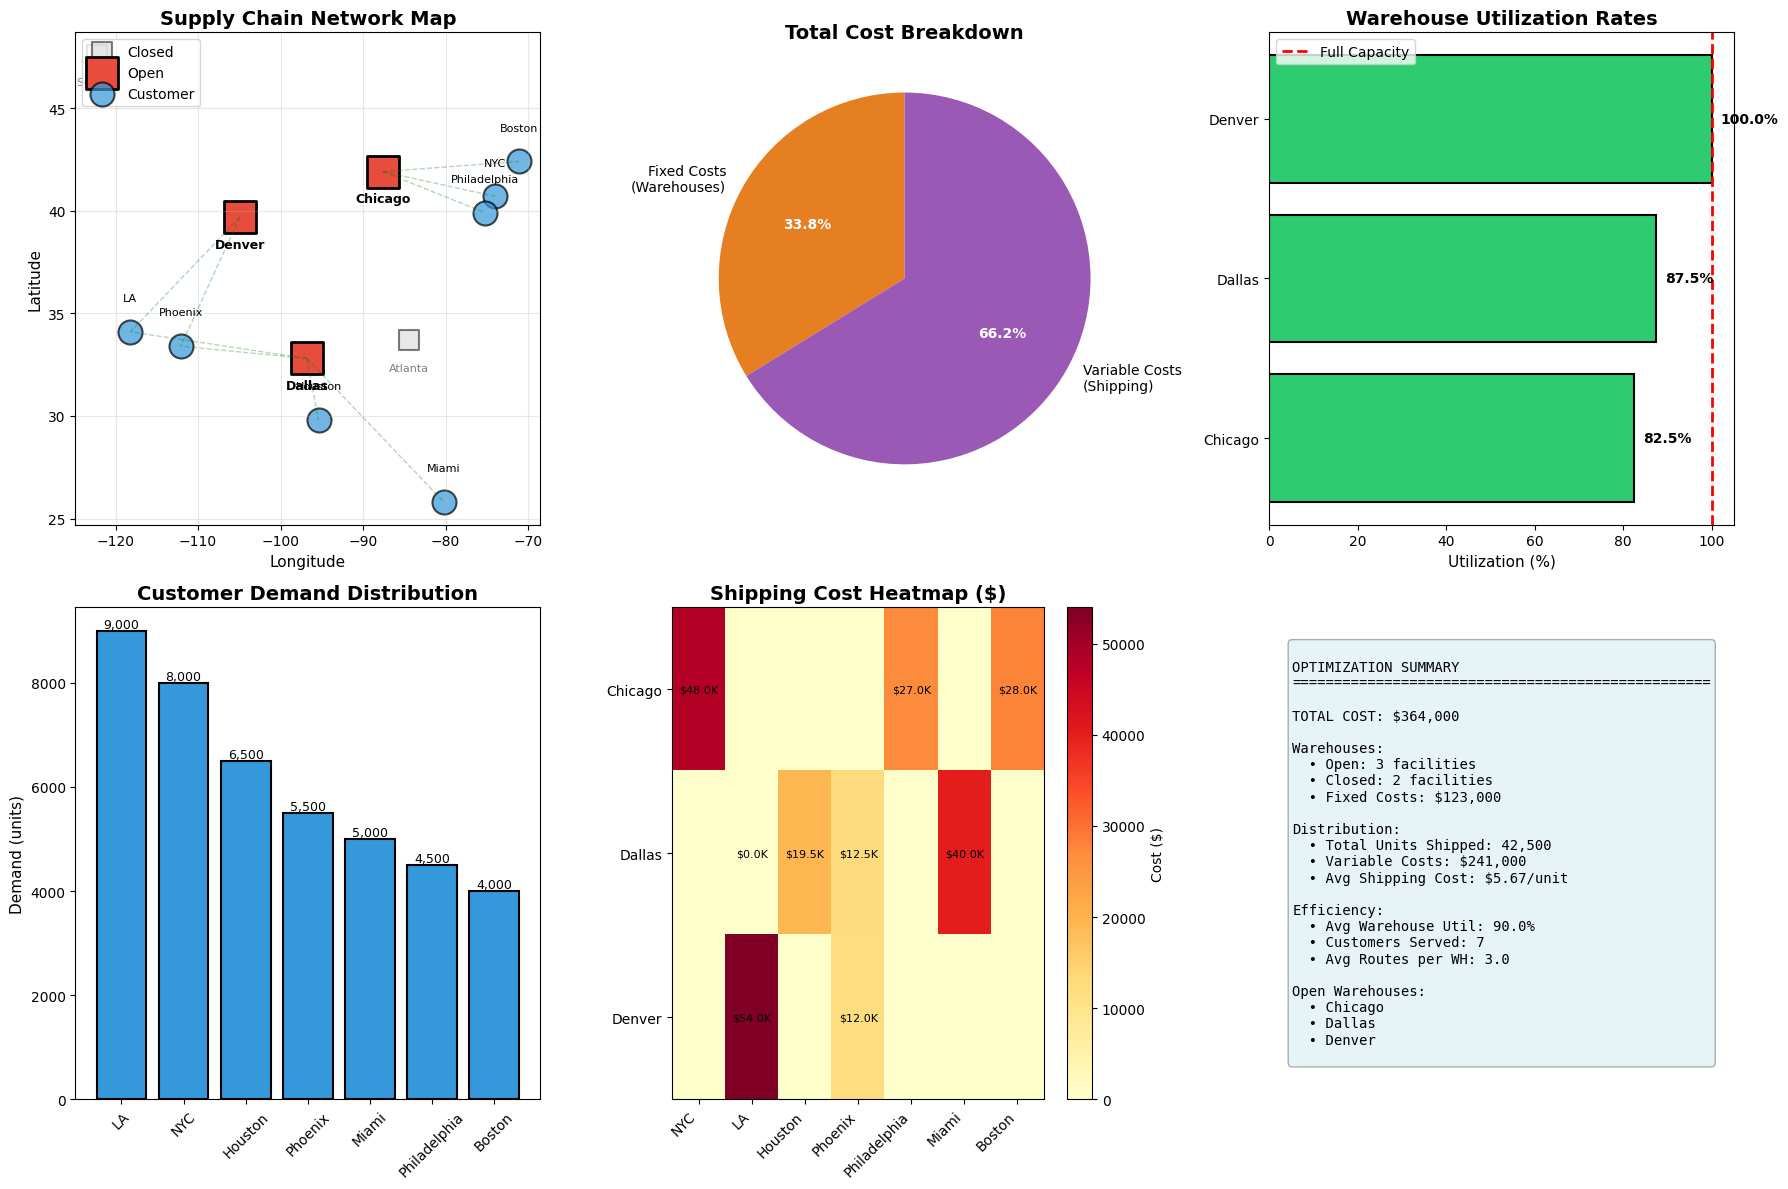

In [14]:
print("STEP 6: GENERATING VISUALIZATIONS")

fig = plt.figure(figsize=(18, 12))

# 1. Network Map
ax1 = plt.subplot(2, 3, 1)
# Plot closed warehouses
for w in closed_warehouses:
    ax1.scatter(warehouses[w]['lon'], warehouses[w]['lat'],
               s=200, c='lightgray', marker='s', edgecolors='black',
               linewidths=1.5, alpha=0.5, label='Closed' if w == closed_warehouses[0] else '')
    ax1.text(warehouses[w]['lon'], warehouses[w]['lat']-1.5, w,
            ha='center', fontsize=8, alpha=0.5)

# Plot open warehouses
for w in open_warehouses:
    ax1.scatter(warehouses[w]['lon'], warehouses[w]['lat'],
               s=500, c='#e74c3c', marker='s', edgecolors='black',
               linewidths=2, label='Open' if w == open_warehouses[0] else '')
    ax1.text(warehouses[w]['lon'], warehouses[w]['lat']-1.5, w,
            ha='center', fontsize=9, fontweight='bold')

# Plot customers
for c in customer_list:
    ax1.scatter(customers[c]['lon'], customers[c]['lat'],
               s=300, c='#3498db', marker='o', edgecolors='black',
               linewidths=1.5, alpha=0.7, label='Customer' if c == customer_list[0] else '')
    ax1.text(customers[c]['lon'], customers[c]['lat']+1.5, c,
            ha='center', fontsize=8)

# Draw shipping routes
for _, route in df_shipping_plan.iterrows():
    w = route['Warehouse']
    c = route['Customer']
    ax1.plot([warehouses[w]['lon'], customers[c]['lon']],
            [warehouses[w]['lat'], customers[c]['lat']],
            'g--', alpha=0.3, linewidth=1)

ax1.set_xlabel('Longitude', fontsize=11)
ax1.set_ylabel('Latitude', fontsize=11)
ax1.set_title('Supply Chain Network Map', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Cost Breakdown
ax2 = plt.subplot(2, 3, 2)
costs = [fixed_cost_total, variable_cost_total]
labels = ['Fixed Costs\n(Warehouses)', 'Variable Costs\n(Shipping)']
colors = ['#e67e22', '#9b59b6']
wedges, texts, autotexts = ax2.pie(costs, labels=labels, autopct='%1.1f%%',
                                     colors=colors, startangle=90,
                                     textprops={'fontsize': 10})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax2.set_title('Total Cost Breakdown', fontsize=14, fontweight='bold')

# 3. Warehouse Utilization
ax3 = plt.subplot(2, 3, 3)
warehouses_open = open_warehouses
utilization = [(sum(x[(w, c)].varValue for c in customer_list) / warehouses[w]['capacity']) * 100
               for w in warehouses_open]
colors_util = ['#2ecc71' if u >= 80 else '#f39c12' if u >= 60 else '#e74c3c' for u in utilization]
bars = ax3.barh(warehouses_open, utilization, color=colors_util, edgecolor='black', linewidth=1.5)
ax3.axvline(x=100, color='red', linestyle='--', linewidth=2, label='Full Capacity')
ax3.set_xlabel('Utilization (%)', fontsize=11)
ax3.set_title('Warehouse Utilization Rates', fontsize=14, fontweight='bold')
ax3.set_xlim(0, 105)
ax3.legend()
for i, (bar, util) in enumerate(zip(bars, utilization)):
    ax3.text(util + 2, bar.get_y() + bar.get_height()/2,
            f'{util:.1f}%', va='center', fontsize=10, fontweight='bold')

# 4. Shipping volume by customer
ax4 = plt.subplot(2, 3, 4)
customer_volumes = {c: customers[c]['demand'] for c in customer_list}
customers_sorted = sorted(customer_volumes.items(), key=lambda x: x[1], reverse=True)
cust_names = [c[0] for c in customers_sorted]
volumes = [c[1] for c in customers_sorted]
bars = ax4.bar(cust_names, volumes, color='#3498db', edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Demand (units)', fontsize=11)
ax4.set_title('Customer Demand Distribution', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
for bar, vol in zip(bars, volumes):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(vol):,}', ha='center', va='bottom', fontsize=9)

# 5. Shipping cost heatmap
ax5 = plt.subplot(2, 3, 5)
shipping_matrix = []
for w in open_warehouses:
    row = [x[(w, c)].varValue * shipping_costs[w][c] for c in customer_list]
    shipping_matrix.append(row)

im = ax5.imshow(shipping_matrix, cmap='YlOrRd', aspect='auto')
ax5.set_xticks(range(len(customer_list)))
ax5.set_yticks(range(len(open_warehouses)))
ax5.set_xticklabels(customer_list, rotation=45, ha='right')
ax5.set_yticklabels(open_warehouses)
ax5.set_title('Shipping Cost Heatmap ($)', fontsize=14, fontweight='bold')

# Add values to heatmap
for i in range(len(open_warehouses)):
    for j in range(len(customer_list)):
        value = shipping_matrix[i][j]
        if value > 0:
            text = ax5.text(j, i, f'${value/1000:.1f}K',
                          ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, ax=ax5, label='Cost ($)')

# 6. Summary Dashboard
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

summary_text = f"""
OPTIMIZATION SUMMARY
{'='*50}

TOTAL COST: ${total_cost:,.0f}

Warehouses:
  • Open: {len(open_warehouses)} facilities
  • Closed: {len(closed_warehouses)} facilities
  • Fixed Costs: ${fixed_cost_total:,}

Distribution:
  • Total Units Shipped: {sum(customers[c]['demand'] for c in customer_list):,}
  • Variable Costs: ${variable_cost_total:,.0f}
  • Avg Shipping Cost: ${variable_cost_total/sum(customers[c]['demand'] for c in customer_list):.2f}/unit

Efficiency:
  • Avg Warehouse Util: {np.mean(utilization):.1f}%
  • Customers Served: {len(customer_list)}
  • Avg Routes per WH: {len(df_shipping_plan)/len(open_warehouses):.1f}

Open Warehouses:
{chr(10).join(f"  • {w}" for w in open_warehouses)}
"""

ax6.text(0.05, 0.5, summary_text, fontsize=10, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.savefig('supply_chain_optimization_results.png', dpi=300, bbox_inches='tight')
print("\n Visualizations saved!")

In [15]:
print("STEP 7: WHAT-IF SCENARIO ANALYSIS")

print("\n WHAT-IF: If we MUST open at least 3 warehouses?")

# Create scenario model
prob_scenario = pulp.LpProblem("Scenario_Min3_Warehouses", pulp.LpMinimize)

# Same variables and objective
y_s = pulp.LpVariable.dicts("OpenWarehouse_S", warehouse_list, cat='Binary')
x_s = pulp.LpVariable.dicts("Ship_S",
                            [(w, c) for w in warehouse_list for c in customer_list],
                            lowBound=0, cat='Continuous')

fixed_costs_s = pulp.lpSum([warehouses[w]['fixed_cost'] * y_s[w] for w in warehouse_list])
shipping_costs_s = pulp.lpSum([shipping_costs[w][c] * x_s[(w, c)]
                               for w in warehouse_list for c in customer_list])
prob_scenario += fixed_costs_s + shipping_costs_s

# Add minimum warehouse constraint
prob_scenario += pulp.lpSum([y_s[w] for w in warehouse_list]) >= 3, "Min_Warehouses"

# Same other constraints
for c in customer_list:
    prob_scenario += pulp.lpSum([x_s[(w, c)] for w in warehouse_list]) == customers[c]['demand']

for w in warehouse_list:
    prob_scenario += pulp.lpSum([x_s[(w, c)] for c in customer_list]) <= warehouses[w]['capacity'] * y_s[w]

for w in warehouse_list:
    for c in customer_list:
        prob_scenario += x_s[(w, c)] <= customers[c]['demand'] * y_s[w]

prob_scenario.solve(pulp.PULP_CBC_CMD(msg=0))

scenario_cost = pulp.value(prob_scenario.objective)
scenario_warehouses = [w for w in warehouse_list if y_s[w].varValue > 0.5]

print(f"\nScenario Result:")
print(f"  • Cost: ${scenario_cost:,.2f} (vs original ${total_cost:,.2f})")
print(f"  • Difference: ${scenario_cost - total_cost:,.2f} ({((scenario_cost/total_cost)-1)*100:+.1f}%)")
print(f"  • Warehouses: {', '.join(scenario_warehouses)}")

STEP 7: WHAT-IF SCENARIO ANALYSIS

 WHAT-IF: If we MUST open at least 3 warehouses?

Scenario Result:
  • Cost: $364,000.00 (vs original $364,000.00)
  • Difference: $0.00 (+0.0%)
  • Warehouses: Chicago, Dallas, Denver
